# AIS Destination Cleaning & Country/Port Mapping (v3)

### Progressive resampling 15 → 10 → 5 → 3 min + similarity score (1–10) + full transform log

**Goal**
- Clean noisy free-text AIS `destination`
- Map to a **port name** or **country name** when the match is confident
- Keep cleaned text when score is below threshold (including unresolved typos)
- Store a **similarity score (1–10)** on every row
- Produce a full **transform log** and a **unique-value frequency** view of the final destinations

**This version**
- Loads **ALL original input columns**
- Adds all cleaning / mapping columns
- Original raw value kept as `destination_original`
- **Final cleaned value is named `destination`**

**Grouping key**: `mmsi`  
**Aggregation**: mode of non-null countries/ports inside each time window  
**Stack**: pure **pandas** + **rapidfuzz**



## 1. Imports, paths & **configurable threshold**

Change `SIMILARITY_THRESHOLD` anytime (1–10).  
Only matches with score ≥ threshold become the final destination.



In [1]:
import pandas as pd
import numpy as np
import json
import re
from pathlib import Path
from collections import defaultdict

from rapidfuzz import fuzz, process
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 140)

# ============================================================
# YOU CONTROL THIS (1-10). Raise for stricter matches.
# ============================================================
SIMILARITY_THRESHOLD = 7
# ============================================================

AIS_PATH = '/home/dd-user3/shubhamk/data_analysis_parquet/data_inst-dd_mp_etl02.parquet'
PORTS_PATH = '/home/dd-user3/shubhamk/data_analysis_parquet/ports_parquet.xlsx'
OUT_DIR = Path('/home/dd-user3/shubhamk/data_analysis_parquet/full_column_output/artifacts')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Libraries loaded. SIMILARITY_THRESHOLD = {SIMILARITY_THRESHOLD}')



Libraries loaded. SIMILARITY_THRESHOLD = 7


## 2. Load AIS data (**all columns**)

Load the full input file. Add `row_index` so the transform log can point back to the original row.

Later: original raw value → `destination_original`, cleaned result → `destination`.



In [2]:
# Load ALL original columns (no column subset)
df = pd.read_parquet(AIS_PATH)
df.insert(0, 'row_index', np.arange(len(df)))

print(f'Shape: {df.shape}')
print(f"destination nulls: {df['destination'].isna().sum():,} "
      f"({df['destination'].isna().mean()*100:.1f}%)")
print(f"Unique raw destinations: {df['destination'].nunique():,}")
print(f"Columns ({len(df.columns)}): {list(df.columns)}")
df.head(3)



Shape: (1023554, 43)
destination nulls: 173,139 (16.9%)
Unique raw destinations: 13,952
Columns (43): ['row_index', 'source_id', 'msg_type', 'vessel_class', 'vessel_type', 'length', 'width', 'draught', 'voyage_id', 'destination', 'eta', 'navigational_status', 'position_approximate', 'cog_approximate', 'sog_approximate', 'timestamp_updated', 'timestamp_received', 'timestamp_created', 'mmsi', 'imo_number', 'vessel_name', 'callsign', 'vessel_id', 'vessel_instance_id', 'longitude', 'latitude', 'cog', 'sog', 'geohash', 'true_heading', 'trackpoint_id', 'track_id', 'track_instance_id', 'obs_type', 'country_code', 'flag_code', 'mmsi_type', 'master_vessel_id', 'master_vessel_name', 'master_imo_number', 'schema_ver', 'data_quality_flags', 'data_quality_score']


,row_index,source_id,msg_type,vessel_class,vessel_type,length,width,draught,voyage_id,destination,eta,navigational_status,position_approximate,cog_approximate,sog_approximate,timestamp_updated,timestamp_received,timestamp_created,mmsi,imo_number,...,vessel_instance_id,longitude,latitude,cog,sog,geohash,true_heading,trackpoint_id,track_id,track_instance_id,obs_type,country_code,flag_code,mmsi_type,master_vessel_id,master_vessel_name,master_imo_number,schema_ver,data_quality_flags,data_quality_score
0,0,50,19,B,30,10.0,5.0,NaN,VMV0000000001-6b86b273-e3b0c442-NAD-NAT,NaN,NaN,NaN,False,False,False,2026-06-01 23:47:32+00:00,2026-06-01 23:53:14.474000+00:00,2026-06-01 23:54:52.596000+00:00,1,NaN,...,VMV0000000001-6b86b273-e3b0c442,56.857433,24.990640,137.800003,0.0,tk2qjv6m,NaN,TPT25391786622163389587,MMSI0000000001,MMSI0000000001-NYA,measured,,000,illegal_mmsi,NaN,NaN,NaN,3.2.0,385,0.0
1,1,50,19,B,0,NaN,NaN,NaN,VMV0000000001-6b86b273-10314348-NAD-NAT,NaN,NaN,NaN,False,False,False,2026-06-01 23:57:13+00:00,2026-06-02 00:09:21.195000+00:00,2026-06-02 00:11:04.178000+00:00,1,NaN,...,VMV0000000001-6b86b273-10314348,56.857498,24.990665,79.500000,0.0,tk2qjv6m,NaN,TPT25391806585171381395,MMSI0000000001,MMSI0000000001-NYA,measured,,000,illegal_mmsi,NaN,NaN,NaN,3.2.0,385,0.0
2,2,50,18,B,0,NaN,NaN,NaN,VMV0000000005-ef2d127d-1a03ef9f-NAD-NAT,NaN,NaN,NaN,False,False,False,2026-06-01 23:10:24+00:00,2026-06-01 23:15:09.060000+00:00,2026-06-01 23:16:38.281000+00:00,5,NaN,...,VMV0000000005-ef2d127d-1a03ef9f,80.293318,-32.207008,81.300003,2.8,mf30g0gu,NaN,TPT25391710062290853010,MMSI0000000005,MMSI0000000005-NYA,measured,,000,illegal_mmsi,NaN,NaN,NaN,3.2.0,385,0.0


## 3. Load ports reference

Use `name`, `alternate_name`, and `locode` / `country` from `addl_details`.
Normalize forms like `Port X`, `X Port`, etc.



In [3]:
ports = pd.read_excel(PORTS_PATH)

def safe_json(x):
    if pd.isna(x):
        return {}
    try:
        return json.loads(x) if isinstance(x, str) else (x if isinstance(x, dict) else {})
    except Exception:
        return {}

ports['_a'] = ports['addl_details'].apply(safe_json)
ports['country'] = ports['_a'].apply(lambda d: d.get('country'))
ports['locode'] = ports['_a'].apply(lambda d: d.get('locode'))
ports['alternate_name'] = ports['_a'].apply(lambda d: d.get('alternate_name'))

print(f'Ports: {ports.shape}')
print(f"Countries: {ports['country'].nunique()}")
print(f"With LOCODE: {ports['locode'].notna().sum()}")
ports[['name', 'locode', 'country']].head(5)



Ports: (3804, 28)
Countries: 195
With LOCODE: 3345


,name,locode,country
0,Maurer,NaN,United States
1,Iharana,NaN,Madagascar
2,Chake Chake,NaN,Tanzania
3,Mjimwema Terminal,NaN,Tanzania
4,Delta Terminal,NaN,Turkey


## 4. Build lookup dictionaries + candidate list for fuzzy matching

Candidates for fuzzy search:
- Port names (and stripped PORT / HARBOUR variants)
- Alternate names
- Country names
- LOCODEs
- Hand-curated AIS aliases



In [4]:
ISO2 = {
    "SG": "Singapore", "CN": "China", "IN": "India", "MY": "Malaysia", "ID": "Indonesia",
    "SA": "Saudi Arabia", "AE": "United Arab Emirates", "VN": "Vietnam", "LK": "Sri Lanka",
    "EG": "Egypt", "AU": "Australia", "ZA": "South Africa", "BR": "Brazil", "JP": "Japan",
    "TH": "Thailand", "BD": "Bangladesh", "PK": "Pakistan", "OM": "Oman", "QA": "Qatar",
    "BH": "Bahrain", "KW": "Kuwait", "TR": "Turkey", "RU": "Russia", "US": "United States",
    "GB": "United Kingdom", "TZ": "Tanzania", "KE": "Kenya", "MZ": "Mozambique",
    "MU": "Mauritius", "MV": "Maldives", "PH": "Philippines", "TW": "Taiwan",
    "KR": "South Korea", "HK": "Hong Kong", "NL": "Netherlands", "DE": "Germany",
    "FR": "France", "ES": "Spain", "IT": "Italy", "GR": "Greece", "NO": "Norway",
    "SE": "Sweden", "DK": "Denmark", "BE": "Belgium", "PT": "Portugal", "PL": "Poland",
    "IR": "Iran", "IQ": "Iraq", "YE": "Yemen", "DJ": "Djibouti", "NG": "Nigeria",
    "GH": "Ghana", "MG": "Madagascar", "NZ": "New Zealand", "CL": "Chile", "PE": "Peru",
    "MX": "Mexico", "CA": "Canada", "AR": "Argentina", "UY": "Uruguay", "CO": "Colombia",
    "PA": "Panama", "EC": "Ecuador", "CI": "Cote d'Ivoire", "SN": "Senegal", "CM": "Cameroon",
    "GA": "Gabon", "CG": "Congo (Brazzaville)", "CD": "Congo (Kinshasa)", "AO": "Angola",
    "NA": "Namibia", "RE": "Reunion", "SC": "Seychelles", "FJ": "Fiji", "PG": "Papua New Guinea",
}

def normalize(text):
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return ""
    text = str(text).upper().strip()
    text = re.sub(r"[^A-Z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def strip_port_words(name):
    n = normalize(name)
    n = re.sub(r"\b(PORT|HARBOUR|HARBOR|TERMINAL|ANCHORAGE|BAY)\b", " ", n)
    return re.sub(r"\s+", " ", n).strip()

locode_map = {}
for _, r in ports.dropna(subset=["locode", "country"]).iterrows():
    c = str(r["locode"]).upper().replace(" ", "")
    if len(c) >= 5:
        locode_map[c[:5]] = r["country"]

exact_map = {}

for _, r in ports.dropna(subset=["name"]).iterrows():
    label = str(r["name"]).strip()
    country = r["country"] if pd.notna(r["country"]) else None
    for key in {normalize(label), strip_port_words(label)}:
        if len(key) >= 3:
            exact_map[key] = (label, "port")
    if country:
        exact_map[normalize(country)] = (str(country).strip(), "country")

for _, r in ports.dropna(subset=["alternate_name"]).iterrows():
    alt = str(r["alternate_name"]).strip()
    label = str(r["name"]).strip() if pd.notna(r["name"]) else alt
    for key in {normalize(alt), strip_port_words(alt)}:
        if len(key) >= 3:
            exact_map[key] = (label, "port")

for name in ISO2.values():
    exact_map[normalize(name)] = (name, "country")

ALIASES = {
    "SINGAPORE": ("Singapore", "country"), "SGSIN": ("Singapore", "country"),
    "SG SIN": ("Singapore", "country"), "SINGAP": ("Singapore", "country"),
    "SIN": ("Singapore", "country"), "SG": ("Singapore", "country"),
    "CHINA": ("China", "country"), "CNSHA": ("China", "country"), "CNYTN": ("China", "country"),
    "SHENZHEN": ("China", "country"), "XIAMEN": ("China", "country"),
    "XIA MEN": ("China", "country"), "SHANGHAI": ("China", "country"),
    "INDIA": ("India", "country"), "MUMBAI": ("India", "country"),
    "INMUN": ("India", "country"), "CHENNAI": ("India", "country"),
    "MALAYSIA": ("Malaysia", "country"), "MYPKG": ("Malaysia", "country"),
    "MY PKG": ("Malaysia", "country"), "JOHOR": ("Malaysia", "country"),
    "JOHOR PORT": ("Malaysia", "country"), "PENGERANG": ("Malaysia", "country"),
    "BATAM": ("Indonesia", "country"), "INDONESIA": ("Indonesia", "country"),
    "JAKARTA": ("Indonesia", "country"), "IDJKT": ("Indonesia", "country"),
    "BALIKOBAN": ("Indonesia", "country"),
    "SAUDI": ("Saudi Arabia", "country"), "SAUDI ARABIA": ("Saudi Arabia", "country"),
    "JEDDAH": ("Saudi Arabia", "country"), "SAJED": ("Saudi Arabia", "country"),
    "SA JED": ("Saudi Arabia", "country"), "SA YNB": ("Saudi Arabia", "country"),
    "SAYNB": ("Saudi Arabia", "country"), "YANBU": ("Saudi Arabia", "country"),
    "DAMMAM": ("Saudi Arabia", "country"), "KSA": ("Saudi Arabia", "country"),
    "UAE": ("United Arab Emirates", "country"), "DUBAI": ("United Arab Emirates", "country"),
    "AJMAN": ("United Arab Emirates", "country"),
    "VIETNAM": ("Vietnam", "country"), "VUNG TAU": ("Vietnam", "country"),
    "VUNGTAU": ("Vietnam", "country"), "HO CHI MINH": ("Vietnam", "country"), "VN": ("Vietnam", "country"),
    "SRI LANKA": ("Sri Lanka", "country"), "COLOMBO": ("Sri Lanka", "country"),
    "LKCMB": ("Sri Lanka", "country"),
    "SUEZ": ("Egypt", "country"), "EGYPT": ("Egypt", "country"),
    "AUSTRALIA": ("Australia", "country"), "SOUTH AFRICA": ("South Africa", "country"),
    "DURBAN": ("South Africa", "country"), "BRAZIL": ("Brazil", "country"),
    "JAPAN": ("Japan", "country"), "THAILAND": ("Thailand", "country"),
    "BANGLADESH": ("Bangladesh", "country"), "PAKISTAN": ("Pakistan", "country"),
    "KARACHI": ("Pakistan", "country"), "OMAN": ("Oman", "country"),
    "QATAR": ("Qatar", "country"), "BAHRAIN": ("Bahrain", "country"),
    "KUWAIT": ("Kuwait", "country"), "TURKEY": ("Turkey", "country"),
    "RUSSIA": ("Russia", "country"),
    "USA": ("United States", "country"), "UNITED STATES": ("United States", "country"),
    "UK": ("United Kingdom", "country"), "UNITED KINGDOM": ("United Kingdom", "country"),
    "TANZANIA": ("Tanzania", "country"), "KENYA": ("Kenya", "country"),
    "MOMBASA": ("Kenya", "country"), "MOZAMBIQUE": ("Mozambique", "country"),
    "MAURITIUS": ("Mauritius", "country"), "MALDIVES": ("Maldives", "country"),
    "MALE": ("Maldives", "country"), "PHILIPPINES": ("Philippines", "country"),
    "TAIWAN": ("Taiwan", "country"), "SOUTH KOREA": ("South Korea", "country"),
    "KOREA": ("South Korea", "country"), "HONG KONG": ("Hong Kong", "country"),
    "FOR ORDERS": ("FOR ORDERS", "special"), "FOR ORDER": ("FOR ORDERS", "special"),
    "ORDER": ("FOR ORDERS", "special"),
}
for k, v in ALIASES.items():
    exact_map[normalize(k)] = v

fuzzy_choices = []
seen_keys = set()
for key, (label, kind) in exact_map.items():
    if key and key not in seen_keys and len(key) >= 3:
        fuzzy_choices.append(key)
        seen_keys.add(key)

key_to_label = dict(exact_map)

print(f"Exact map keys: {len(exact_map)}")
print(f"Fuzzy candidates: {len(fuzzy_choices)}")
print(f"LOCODE map: {len(locode_map)}")
print(f"Aliases: {len(ALIASES)}")



Exact map keys: 5376
Fuzzy candidates: 5373
LOCODE map: 3313
Aliases: 85


## 5. Clean destination text

Produces `dest_clean` from the raw `destination` column.



In [5]:
def clean_one(raw):
    if raw is None or (isinstance(raw, float) and np.isnan(raw)):
        return None
    s = str(raw).upper().strip()
    if not s or s in ('NAN', 'NONE', 'NULL'):
        return None
    s = re.sub(r'[><]+', ' ', s)
    s = re.sub(r'[^A-Z0-9\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    if len(s) <= 1 or re.fullmatch(r'[0-9\s]+', s):
        return None
    return s

df['dest_clean'] = df['destination'].map(clean_one)
print(f"Non-null cleaned: {df['dest_clean'].notna().sum():,}")
print(f"Unique cleaned:   {df['dest_clean'].nunique():,}")
df[['destination', 'dest_clean']].dropna(subset=['destination']).drop_duplicates('destination').head(12)



Non-null cleaned: 839,642
Unique cleaned:   12,810


,destination,dest_clean
71,ORDER,ORDER
74,APAN,APAN
259,147368MARINE FS,147368MARINE FS
326,SAE AND PORT,SAE AND PORT
388,ORE/ALLCHINESE,ORE ALLCHINESE
391,NEWYOPAN,NEWYOPAN
392,NEWYORK,NEWYORK
433,NEWYOP,NEWYOP
466,BGC,BGC
478,TEST HARBOR,TEST HARBOR


## 6. Match cleaned text → port / country (score 1–10)



In [6]:
def ratio_to_score_1_10(ratio_0_100):
    if ratio_0_100 is None or ratio_0_100 <= 0:
        return 1
    s = int(round(ratio_0_100 / 10.0))
    return max(1, min(10, s))


def match_one(cleaned):
    if cleaned is None or (isinstance(cleaned, float) and np.isnan(cleaned)):
        return (None, 1, "was_null", "none")
    if not isinstance(cleaned, str):
        cleaned = str(cleaned)
    cleaned = cleaned.strip()
    if not cleaned:
        return (None, 1, "was_null", "none")

    tokens = cleaned.split()
    compact = cleaned.replace(" ", "")

    if cleaned in exact_map:
        label, kind = exact_map[cleaned]
        return (label, 10, "exact_full", kind)
    if normalize(cleaned) in exact_map:
        label, kind = exact_map[normalize(cleaned)]
        return (label, 10, "exact_norm", kind)

    if len(compact) >= 5 and compact[:5] in locode_map:
        return (locode_map[compact[:5]], 10, "locode", "country")
    for t in tokens:
        if len(t) == 5 and t in locode_map:
            return (locode_map[t], 10, "locode", "country")
        if len(t) > 5 and t[:5] in locode_map:
            return (locode_map[t[:5]], 10, "locode", "country")

    for t in tokens:
        if len(t) == 2 and t in ISO2:
            return (ISO2[t], 10, "iso2_code", "country")
        if len(t) == 5 and t[:2] in ISO2 and t[2:].isalpha():
            return (ISO2[t[:2]], 9, "iso2_from_locode", "country")

    for t in tokens:
        if t in exact_map and len(t) >= 3:
            label, kind = exact_map[t]
            return (label, 10, "exact_token", kind)
    for n in range(len(tokens), 1, -1):
        ph = " ".join(tokens[:n])
        if ph in exact_map:
            label, kind = exact_map[ph]
            return (label, 10, "exact_phrase", kind)

    if len(cleaned) >= 3 and fuzzy_choices:
        hit = process.extractOne(
            cleaned,
            fuzzy_choices,
            scorer=fuzz.WRatio,
            score_cutoff=50,
        )
        if hit is not None:
            key, ratio, _ = hit
            ratio2 = fuzz.token_sort_ratio(cleaned, key)
            ratio3 = fuzz.partial_ratio(cleaned, key)
            best_ratio = max(ratio, ratio2, ratio3)
            score = ratio_to_score_1_10(best_ratio)
            label, kind = key_to_label.get(key, (key, "port"))
            return (label, score, "fuzzy", kind)

    return (None, 1, "no_match", "none")


unique_clean = df["dest_clean"].dropna().unique().tolist()
print(f"Unique cleaned values to score: {len(unique_clean):,}")

cache = {}
for i, u in enumerate(unique_clean):
    cache[u] = match_one(u)
    if (i + 1) % 2000 == 0:
        print(f"  scored {i+1:,} / {len(unique_clean):,}")

print("Scoring all rows via cache...")
labels, scores, methods, kinds = [], [], [], []
for c in df["dest_clean"].tolist():
    if c is None or (isinstance(c, float) and np.isnan(c)):
        labels.append(None); scores.append(1); methods.append("was_null"); kinds.append("none")
    else:
        lab, sc, meth, kind = cache[c]
        labels.append(lab); scores.append(sc); methods.append(meth); kinds.append(kind)

df["matched_label"] = labels
df["similarity_score"] = scores
df["match_method"] = methods
df["match_kind"] = kinds

df["matched_accepted"] = np.where(
    (df["matched_label"].notna()) & (df["similarity_score"] >= SIMILARITY_THRESHOLD),
    df["matched_label"],
    np.nan,
)

print(f"\nThreshold = {SIMILARITY_THRESHOLD}")
print(f"Rows with accepted match: {df['matched_accepted'].notna().sum():,} "
      f"({df['matched_accepted'].notna().mean()*100:.1f}%)")
print("\nScore distribution (1-10):")
print(df["similarity_score"].value_counts().sort_index().to_string())
print("\nMatch methods:")
print(df["match_method"].value_counts().head(12).to_string())
print("\nTop accepted labels:")
print(df["matched_accepted"].value_counts().head(15).to_string())



Unique cleaned values to score: 12,810
  scored 2,000 / 12,810
  scored 4,000 / 12,810
  scored 6,000 / 12,810
  scored 8,000 / 12,810
  scored 10,000 / 12,810
  scored 12,000 / 12,810
Scoring all rows via cache...

Threshold = 7
Rows with accepted match: 830,192 (81.1%)

Score distribution (1-10):
similarity_score
1     190005
6       3357
7      18169
8      72060
9     202102
10    537861

Match methods:
match_method
fuzzy               276373
exact_full          199290
was_null            183912
locode              164528
iso2_code            80152
iso2_from_locode     70522
exact_token          40763
no_match              6093
exact_phrase          1921

Top accepted labels:
matched_accepted
Singapore                 95483
China                     61415
India                     41422
Saudi Arabia              41076
Malaysia                  38343
Indonesia                 29249
Vietnam                   22361
Sri Lanka                 18006
FOR ORDERS                14128
Egypt 

## 7. Progressive resampling 15 → 10 → 5 → 3 min

Mode of accepted labels per MMSI inside each time window.



In [7]:
df['timestamp_updated'] = pd.to_datetime(df['timestamp_updated'], utc=True)
df = df.sort_values(['mmsi', 'timestamp_updated']).reset_index(drop=True)

def safe_mode(s):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    return s.mode().iloc[0]

for freq, col in [
    ('15min', 'label_15min'),
    ('10min', 'label_10min'),
    ('5min', 'label_5min'),
    ('3min', 'label_3min'),
]:
    bins = df['timestamp_updated'].dt.floor(freq)
    df[col] = df.groupby(['mmsi', bins], sort=False)['matched_accepted'].transform(safe_mode)
    print(f'{freq}: non-null = {df[col].notna().sum():,}')



15min: non-null = 845,998
10min: non-null = 842,415
5min: non-null = 838,204
3min: non-null = 835,908


## 8. Build final destination (cascade + fallback to cleaned text)

Intermediate result in `destination_final`.  
Next step renames cleaned value to `destination`.



In [8]:
df['destination_mapped'] = (
    df['label_3min']
      .fillna(df['label_5min'])
      .fillna(df['label_10min'])
      .fillna(df['label_15min'])
      .fillna(df['matched_accepted'])
)

df['destination_final'] = np.where(
    df['destination_mapped'].notna(),
    df['destination_mapped'],
    df['dest_clean'],
)

print(f"Final non-null: {pd.Series(df['destination_final']).notna().sum():,}")
print(f"Final nulls:    {pd.Series(df['destination_final']).isna().sum():,}")



Final non-null: 854,269
Final nulls:    169,285


## 9. Status / transform log + name cleaned value as `destination`

- `destination_original` = original raw AIS value
- `destination` = cleaned final value



In [9]:
status_list, method_list = [], []
orig = df["destination"].tolist()
final = df["destination_final"].tolist()
mm = df["match_method"].tolist()
sc = df["similarity_score"].tolist()
c3 = df["label_3min"].tolist()
c5 = df["label_5min"].tolist()
c10 = df["label_10min"].tolist()
c15 = df["label_15min"].tolist()
dm = df["destination_mapped"].tolist()

for i in range(len(df)):
    o, f, m = orig[i], final[i], mm[i]
    o_null = o is None or (isinstance(o, float) and np.isnan(o))
    f_null = f is None or (isinstance(f, float) and np.isnan(f))

    if o_null and f_null:
        status_list.append("WAS_NULL"); method_list.append("was_null"); continue
    if o_null and not f_null:
        status_list.append("CHANGED"); method_list.append(f"filled_via_{m}"); continue
    if not o_null and f_null:
        status_list.append("CHANGED"); method_list.append("cleared_garbage"); continue

    ou, fu = str(o).strip().upper(), str(f).strip().upper()
    if ou == fu:
        status_list.append("UNCHANGED"); method_list.append("identical"); continue

    if dm[i] is not None and not (isinstance(dm[i], float) and np.isnan(dm[i])) and fu == str(dm[i]).strip().upper():
        if c3[i] is not None and not (isinstance(c3[i], float) and np.isnan(c3[i])) and str(c3[i]) == str(dm[i]):
            status_list.append("CHANGED"); method_list.append(f"resample_3min+{m}")
        elif c5[i] is not None and not (isinstance(c5[i], float) and np.isnan(c5[i])) and str(c5[i]) == str(dm[i]):
            status_list.append("CHANGED"); method_list.append(f"resample_5min+{m}")
        elif c10[i] is not None and not (isinstance(c10[i], float) and np.isnan(c10[i])) and str(c10[i]) == str(dm[i]):
            status_list.append("CHANGED"); method_list.append(f"resample_10min+{m}")
        elif c15[i] is not None and not (isinstance(c15[i], float) and np.isnan(c15[i])) and str(c15[i]) == str(dm[i]):
            status_list.append("CHANGED"); method_list.append(f"resample_15min+{m}")
        else:
            status_list.append("CHANGED"); method_list.append(f"{m}_score{sc[i]}")
        continue

    status_list.append("KEPT_AS_IS"); method_list.append("cleaned_below_threshold_or_no_match")

df["status"] = status_list
df["transform_method"] = method_list

# ---- naming: cleaned final value must be called destination ----
df["destination_original"] = df["destination"]   # keep raw
df["destination"] = df["destination_final"]      # cleaned → destination

print(df["status"].value_counts().to_string())
print()
print("Column naming:")
print("  destination_original = original raw AIS value")
print("  destination          = cleaned final value")
print(f"destination non-null: {df['destination'].notna().sum():,}")



status
CHANGED       782803
WAS_NULL      159442
UNCHANGED      80183
KEPT_AS_IS      1126

Column naming:
  destination_original = original raw AIS value
  destination          = cleaned final value
destination non-null: 854,269


## 10. Quality summary



In [10]:
print('=' * 60)
print('QUALITY SUMMARY')
print('=' * 60)
print(f'Total rows:            {len(df):,}')
print(f'SIMILARITY_THRESHOLD:  {SIMILARITY_THRESHOLD}')
print(f"Original nulls:        {df['destination_original'].isna().sum():,} "
      f"({df['destination_original'].isna().mean()*100:.1f}%)")
print(f"Final nulls:           {df['destination'].isna().sum():,} "
      f"({df['destination'].isna().mean()*100:.1f}%)")
print()
print('--- Status counts ---')
print(f"CHANGED:               {(df['status']=='CHANGED').sum():,}")
print(f"UNCHANGED:             {(df['status']=='UNCHANGED').sum():,}")
print(f"KEPT_AS_IS:            {(df['status']=='KEPT_AS_IS').sum():,}")
print(f"WAS_NULL:              {(df['status']=='WAS_NULL').sum():,}")
print()
print('Score distribution (1-10) on all rows:')
print(df['similarity_score'].value_counts().sort_index().to_string())
print()
print('Sample CHANGED rows:')
print(
    df[df['status'] == 'CHANGED']
    [['row_index', 'destination_original', 'destination', 'similarity_score', 'transform_method']]
    .head(20)
    .to_string(index=False)
)
print()
print('Sample KEPT_AS_IS (unresolved typos etc.):')
print(
    df[df['status'] == 'KEPT_AS_IS']
    [['row_index', 'destination_original', 'destination', 'similarity_score', 'transform_method']]
    .head(15)
    .to_string(index=False)
)



QUALITY SUMMARY
Total rows:            1,023,554
SIMILARITY_THRESHOLD:  7
Original nulls:        173,139 (16.9%)
Final nulls:           169,285 (16.5%)

--- Status counts ---
CHANGED:               782,803
UNCHANGED:             80,183
KEPT_AS_IS:            1,126
WAS_NULL:              159,442

Score distribution (1-10) on all rows:
similarity_score
1     190005
6       3357
7      18169
8      72060
9     202102
10    537861

Sample CHANGED rows:
 row_index destination_original                                   destination  similarity_score         transform_method
        71                ORDER                                    FOR ORDERS                10 resample_3min+exact_full
        72                ORDER                                    FOR ORDERS                10 resample_3min+exact_full
        73                ORDER                                    FOR ORDERS                10 resample_3min+exact_full
        74                 APAN                                

## 11. Changed-rows export



In [11]:
changed = df[df['status'] == 'CHANGED'][
    ['row_index', 'mmsi', 'destination_original', 'destination',
     'similarity_score', 'match_method', 'match_kind', 'transform_method']
].copy()

unchanged_n = (df['status'] == 'UNCHANGED').sum()
kept_n = (df['status'] == 'KEPT_AS_IS').sum()
null_n = (df['status'] == 'WAS_NULL').sum()

print(f'CHANGED rows:   {len(changed):,}')
print(f'UNCHANGED rows: {unchanged_n:,}')
print(f'KEPT_AS_IS:     {kept_n:,}')
print(f'WAS_NULL:       {null_n:,}')

changed_path = OUT_DIR / 'destination_changed_rows.csv'
changed.to_csv(changed_path, index=False)
print(f'\nChanged-rows list written to: {changed_path}')
changed.head(10)



CHANGED rows:   782,803
UNCHANGED rows: 80,183
KEPT_AS_IS:     1,126
WAS_NULL:       159,442

Changed-rows list written to: /home/dd-user3/shubhamk/data_analysis_parquet/full_column_output/artifacts/destination_changed_rows.csv


,row_index,mmsi,destination_original,destination,similarity_score,match_method,match_kind,transform_method
71,71,999,ORDER,FOR ORDERS,10,exact_full,special,resample_3min+exact_full
72,72,999,ORDER,FOR ORDERS,10,exact_full,special,resample_3min+exact_full
73,73,999,ORDER,FOR ORDERS,10,exact_full,special,resample_3min+exact_full
74,74,1111,APAN,Trapani,10,fuzzy,port,resample_3min+fuzzy
75,75,1111,APAN,Trapani,10,fuzzy,port,resample_3min+fuzzy
76,76,1111,APAN,Trapani,10,fuzzy,port,resample_3min+fuzzy
77,77,1111,APAN,Trapani,10,fuzzy,port,resample_3min+fuzzy
78,78,1111,NaN,Trapani,1,was_null,none,filled_via_was_null
259,259,171069,147368MARINE FS,Marin,10,fuzzy,port,resample_3min+fuzzy
326,326,420393,SAE AND PORT,"Saint Helena, Ascension, and Tristan da Cunha",9,fuzzy,country,resample_3min+fuzzy


## 12. Unique-value frequency table

All unique values in the final `destination` column, including:
- country names
- port names
- special values
- unresolved typos / cleaned leftovers
- nulls

Sorted by count descending. Nothing is dropped.



In [12]:
final_series = df['destination'].fillna('__NULL__')
freq = (
    final_series.value_counts(dropna=False)
    .rename_axis('destination')
    .reset_index(name='count')
)
freq['pct'] = (freq['count'] / freq['count'].sum() * 100).round(3)

print(f'Total unique final values (incl. null): {len(freq):,}')
print()
print('Top 40 by frequency:')
print(freq.head(40).to_string(index=False))

freq_path = OUT_DIR / 'destination_unique_frequency.csv'
freq.to_csv(freq_path, index=False)
print(f'\nFull frequency table written to: {freq_path}')



Total unique final values (incl. null): 1,732

Top 40 by frequency:
           destination  count    pct
              __NULL__ 169285 16.539
             Singapore  96090  9.388
                 China  62814  6.137
                 India  41953  4.099
          Saudi Arabia  41375  4.042
              Malaysia  38622  3.773
             Indonesia  29463  2.878
               Vietnam  22347  2.183
             Sri Lanka  18265  1.784
            FOR ORDERS  14598  1.426
                 Egypt  14055  1.373
                Brazil  12134  1.185
          South Africa  11845  1.157
             Australia  11469  1.121
  United Arab Emirates   8607  0.841
Belanak Field Terminal   7879  0.770
            Balikpapan   7217  0.705
                 Assab   6222  0.608
                  Peru   5883  0.575
                  Oman   5819  0.569
                  Muar   5485  0.536
             Hong Kong   5318  0.520
             Guangzhou   5045  0.493
                 Kenya   4997  0.488
       

## 13. Visualize unique-value frequencies (top N)



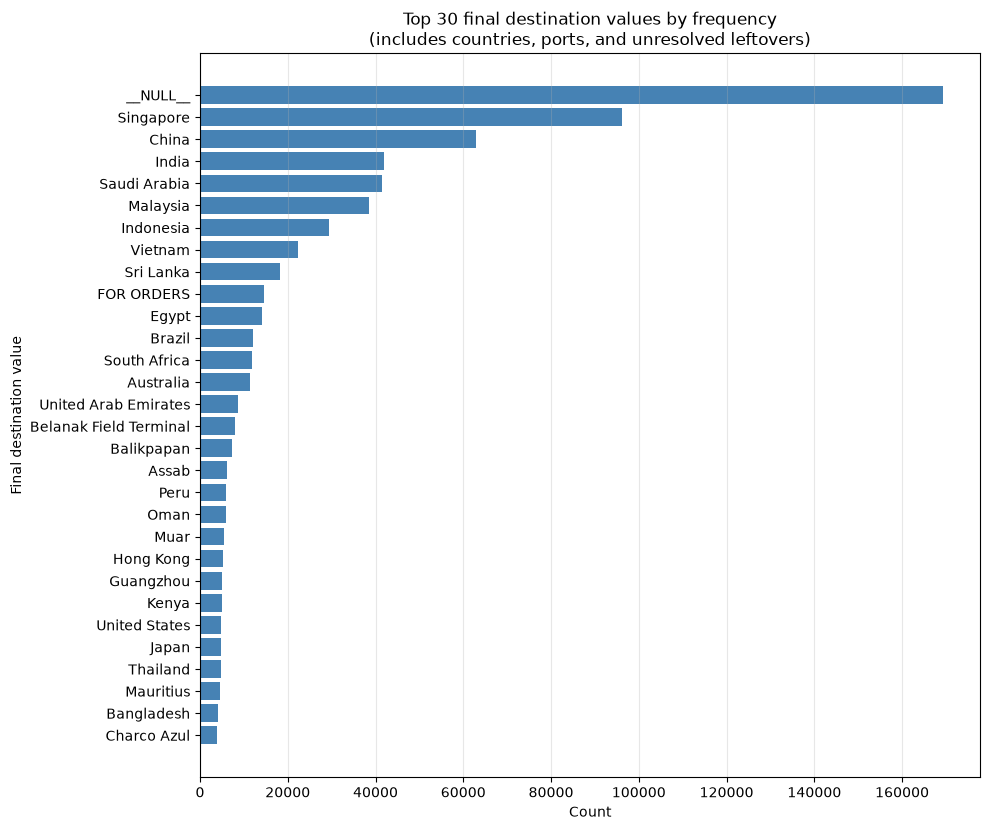

Chart saved: /home/dd-user3/shubhamk/data_analysis_parquet/full_column_output/artifacts/destination_frequency_top30.png


In [13]:
TOP_N = 30  # change if you want more/fewer bars

plot_df = freq.head(TOP_N).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, max(6, TOP_N * 0.28)))
ax.barh(plot_df['destination'].astype(str), plot_df['count'], color='steelblue')
ax.set_xlabel('Count')
ax.set_ylabel('Final destination value')
ax.set_title(
    f'Top {TOP_N} final destination values by frequency\n'
    '(includes countries, ports, and unresolved leftovers)'
)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()

chart_path = OUT_DIR / 'destination_frequency_top30.png'
plt.savefig(chart_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Chart saved: {chart_path}')



## 14. Save outputs (parquet + CSV + transform log)

- Full parquet / CSV: **all original columns + all new cleaning columns**
- `destination` = cleaned final value
- `destination_original` = original raw AIS value
- Rows restored to original order via `row_index`



In [14]:
# Restore original row order (resampling step sorts by mmsi/time)
df = df.sort_values('row_index').reset_index(drop=True)

# Full-width parquet (all original + all new columns)
df.to_parquet(OUT_DIR / 'ais_destination_cleaned_v3.parquet', index=False)

# Full-width CSV
df.to_csv(OUT_DIR / 'ais_destination_cleaned_v3.csv', index=False)

# Transform log (destination-focused)
log = pd.DataFrame({
    'row_index': df['row_index'],
    'column': 'destination',
    'mmsi': df['mmsi'],
    'original_value': df['destination_original'],  # original raw
    'dest_clean': df['dest_clean'],
    'matched_label': df['matched_label'],
    'similarity_score': df['similarity_score'],
    'match_method': df['match_method'],
    'match_kind': df['match_kind'],
    'final_value': df['destination'],              # cleaned final
    'status': df['status'],
    'method': df['transform_method'],
})
log.to_parquet(OUT_DIR / 'destination_transform_log_v3.parquet', index=False)
log.to_csv(OUT_DIR / 'destination_transform_log_v3.csv', index=False)

print('Written:')
for p in [
    'ais_destination_cleaned_v3.parquet',
    'ais_destination_cleaned_v3.csv',
    'destination_transform_log_v3.parquet',
    'destination_transform_log_v3.csv',
    'destination_changed_rows.csv',
    'destination_unique_frequency.csv',
    'destination_frequency_top30.png',
]:
    print(f'  {OUT_DIR / p}')

print(f'\nFinal shape: {df.shape}')
print(f'Final columns ({len(df.columns)}):')
for col in df.columns:
    print(f'  - {col}')
print('Done.')



Written:
  /home/dd-user3/shubhamk/data_analysis_parquet/full_column_output/artifacts/ais_destination_cleaned_v3.parquet
  /home/dd-user3/shubhamk/data_analysis_parquet/full_column_output/artifacts/ais_destination_cleaned_v3.csv
  /home/dd-user3/shubhamk/data_analysis_parquet/full_column_output/artifacts/destination_transform_log_v3.parquet
  /home/dd-user3/shubhamk/data_analysis_parquet/full_column_output/artifacts/destination_transform_log_v3.csv
  /home/dd-user3/shubhamk/data_analysis_parquet/full_column_output/artifacts/destination_changed_rows.csv
  /home/dd-user3/shubhamk/data_analysis_parquet/full_column_output/artifacts/destination_unique_frequency.csv
  /home/dd-user3/shubhamk/data_analysis_parquet/full_column_output/artifacts/destination_frequency_top30.png

Final shape: (1023554, 58)
Final columns (58):
  - row_index
  - source_id
  - msg_type
  - vessel_class
  - vessel_type
  - length
  - width
  - draught
  - voyage_id
  - destination
  - eta
  - navigational_status
  - p

## Reference

| Item | Meaning |
|------|---------|
| `SIMILARITY_THRESHOLD` | You set this (1–10). Only score ≥ threshold is accepted |
| `destination` | **Cleaned final value** (standard name) |
| `destination_original` | Original raw AIS value |
| `destination_final` | Intermediate (same content as `destination` after rename step) |
| `similarity_score` | 1–10 on every row |
| `match_kind` | `port` / `country` / `special` / `none` |
| `status` | `CHANGED` / `UNCHANGED` / `KEPT_AS_IS` / `WAS_NULL` |
| `KEPT_AS_IS` | Cleaned text kept — includes unresolved typos |
| Frequency table | **All** unique final values + counts (nothing dropped) |

Re-run from cell 1 after changing `SIMILARITY_THRESHOLD`.

